### 1. Import requirements and dependencies

In [1]:
# Including the versions I used when developing -->
import pandas as pd #Version 2.2.3
import cobra #Version 0.29.0
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt #Version 3.10.0
from cobra import Model as CobraModel
import warnings
warnings.filterwarnings('ignore', 
                       message='DataFrame is highly fragmented', 
                       category=pd.errors.PerformanceWarning)

### 2. Define LEXicographic Objective Function Finder function

In [2]:
'''
GOAL: Performs a lexicographic optimisation on a COBRA model, to predict the objective function(s) that best satisfy experimental criteria
PROCESS: 
1. First optimisation is assumed by the User and maximisation or minimisation is specified
2. The highest priority is placed on the first optimisation, then this objective value is used as additional model constraints for a second optimisation
3. Second optimisation can be either maximisation or minimisation of any exchange reaction in COBRA model
4. Comparison of predicted fluxes to an experimental criteria, which has been specified by the User

PARAMETERS:
- 'model': A COBRA model, ideally omics constrained (e.g. transcriptomics or proteomics)
- 'first_opt': A reaction ID that is a User assumption of the first objective function
- 'coefficient_1': either 1 or -1 to specify the maximisation or minimisation of 'first_opt'
- 'coefficient_2': either 1 or -1 to specify the maximisation or minimisation of every exchange reaction in turn, to be tested as the second optimisation
- 'criteria': a qualitative experimental criteria, in the form of a dictionary of reaction IDs (keys) and a qualitative flux direction (values) of 1, 0 or -1 for flux in forward direction (i.e. production), 
no flux or flux in reverse direction (i.e. consumption)

Returns:
- Dataframe of predicted absolute fluxes, qualitative fluxes and proportion accuracy to experimental criteria for each lexicographic optimisation. Column headers are reaction ID of second optimisation
- Dictionary: Accuracy scores to criteria (keys) and number of reactions that achieved this score (values)
- Message reporting maximum accuracy score achieved, the number of reactions that achieved this and an example of the first few reactions IDs with maximum accuracy
- Bar plot with the distribution of accuracies achieved by optimisations
'''

def lexoff(model,first_opt,coefficient_1,coefficient_2,criteria):
    # Input validation
    if not isinstance(model, CobraModel):
        raise TypeError("Check inputs: Model must be a cobra.Model.Model instance")
    if not isinstance(criteria, dict):
        raise TypeError("Check inputs: Criteria should be in dictionary format with keys as reaction IDs and values as 1, 0 or -1")
    if coefficient_1 not in (-1, 1):
        raise ValueError("Check inputs: Coefficient 1 must be either 1 or -1")
    if coefficient_2 not in (-1, 1):
        raise ValueError("Check inputs: Coefficient 2 must be either 1 or -1")

    # Ensure exchange reaction boundaries reflect reversibility if the experimental criteria specifies a metabolite uptake
    for k,v in criteria.items():
        if criteria[k] == -1: # If you have specified that there is uptake of this metabolite
            if model.reactions.get_by_id(k).reversibility == False: # But if the inbuilt bounds don't allow uptake of this metabolite...
                model.reactions.get_by_id(k).lower_bound = -1000 # Update the model bounds to allow for metabolite uptake
                print('reaction bounds for:',k,'have been updated from 0,+1000 to -1000,+1000 to allow metabolite uptake')
            else:
                continue # If reversibility is already allowed
        else:
            continue # If criteria specifies 0 flux (0) or production (+1)

    # Print optimisation instructions to confirm to User what they have coded
    if coefficient_1 == 1:
        first_goal = 'maximise'
    if coefficient_1 == -1:
        first_goal = 'minimise'
    if coefficient_2 == 1:
        second_goal = 'maximisation'
    if coefficient_2 == -1:
        second_goal = 'minimisation'
    print(f"Optimisation: User would like to {first_goal} {first_opt}, then explore the {second_goal} of exchange reactions as the second optimisation")
    
    # Set up empty dataframe to append with optimisation results later on
    objectives_df = pd.DataFrame()
    first_col = []
    for k in criteria.keys(): # Add index of reaction IDs for criteria (to insert absolute fluxes)
        first_col.append(k)
    for k in criteria.keys(): # Add index of reaction IDs again (to insert qualitative fluxes)
        first_col.append(k)
    first_col.append('accuracy') # Add index for accuracy to experimental data
    objectives_df['criteria_reactions'] = first_col
    objectives_df = objectives_df.set_index('criteria_reactions')
    criteria_keys = []
    for c in criteria.keys():
        criteria_keys.append(c)
    
    # Make test model and run optimisations
    model_test = model.copy()
    model = model_test
    columns_to_add = {}
    for e in model.exchanges: # Only exchange reactions will be explored within the objective
        with model:
            # First optimisation
            model.objective = {model.reactions.get_by_id(first_opt):coefficient_1}
            objective_sol = model.slim_optimize()
            model.reactions.get_by_id(first_opt).bounds = (objective_sol,objective_sol) # Set objective value as additional constraints
            # Second optimisation
            model.objective = {model.reactions.get_by_id(e.id):coefficient_2}
            solution = model.optimize()
            
            # Fill in dataframe column with absolute solutions, qualitative solutions and accuracy
            # Absolute solutions...
            criteria_solutions = []
            for c in criteria.keys():
                criteria_solutions.append(solution.fluxes[c])
            criteria_col = []
            for c in criteria_solutions:
                criteria_col.append(c)
            qual_values = []
            # Qualitative solution
            for c in criteria_solutions:
                if c>0:
                    criteria_col.append(1)
                    qual_values.append(1)
                if c<0:
                    criteria_col.append(-1)
                    qual_values.append(-1)
                if c==0:
                    criteria_col.append(0)
                    qual_values.append(0)
            true_values = []
            for q in criteria.values():
                true_values.append(q)
            test_values = qual_values
            # Compute and insert accuracy scores
            accuracy = sum(a == b for a, b in zip(true_values, test_values))
            criteria_col.append(accuracy/len(criteria.keys()))
            objectives_df[e.id] = criteria_col
            
    # Sort columns according to accuracy score
    sorted_columns = objectives_df.iloc[-1].sort_values(ascending=True).index
    sorted_df = objectives_df[sorted_columns]
    
    # Create dictionary from dataframe of optimsiation solutions
    accuracies = (sorted_df).iloc[-1]
    unique_accuracies = [float(val) for val in accuracies.unique()]
    accuracy_dict = {val: list(accuracies[accuracies == val].index) for val in unique_accuracies}
    
    # Print message summarising the optimisation results
    max_accuracy = max(unique_accuracies)
    count = len(accuracy_dict[max_accuracy])
    first_few = accuracy_dict[max_accuracy][:3]
    message = f"The maximum accuracy is {max_accuracy} and this has been achieved by {count} unique reactions for second optimisation, including the {second_goal} of: {first_few}"
    print(message)
    
    # Bar plot for distribution of accuracies achieved by optimisations
    x_axis = unique_accuracies
    y_axis = [len(rxns) for rxns in accuracy_dict.values()]
    
    for acc, rxns in accuracy_dict.items():
        print(f"{acc:.2f} accuracy: {len(rxns)} reactions")
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(x_axis, y_axis, color='black', edgecolor='black', width=0.05)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Frequency of Reactions')
    ax.set_title('Distribution of Optimisation Accuracies')
    ax.set_xlim(-0.05, 1.05)
    ax.set_xticks([0] + x_axis + [1])
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Return variables
    return(sorted_df,accuracy_dict,message,fig)

### 3. Import COBRA model and define experimental qualitative criteria

In [3]:
# References: Meeson et al, 2025 (PMID: 40219633); Strain et al, 2023 (PMID: 36866411)

# Import COBRA model (transcriptomics constrained)
# 'constrained_678' is a transcriptomics (day 6, 7 and 8 of fed-batch culture measurements) (Meeson et al, 2025) constrained version of iCHO2441 (Strain et al, 2023) 
%store -r constrained_678 
model = constrained_678

# Define dictionary with experimental criteria
# According to bioprocess measurements from bioreactor
# Criteria equates to active growth, IgG product formation, Lactate consumption (or negative production) and ammonia consumption (or negative production)
late_qual_criteria_dict = {'biomass_cho_prod':1,'ICproduct_Final_demand':1,'EX_lac_L(e)':-1,'EX_nh4(e)':-1} 

### 4a. Run LEXOFF (example with maximisation of second optimisation)

Optimisation: User would like to maximise biomass_cho_prod, then explore the maximisation of exchange reactions as the second optimisation
The maximum accuracy is 0.75 and this has been achieved by 24 unique reactions for second optimisation, including the maximisation of: ['EX_ksi(e)', 'EX_idp(e)', 'EX_imp(e)']
0.25 accuracy: 337 reactions
0.50 accuracy: 184 reactions
0.75 accuracy: 24 reactions
CPU times: total: 51.9 s
Wall time: 52.7 s


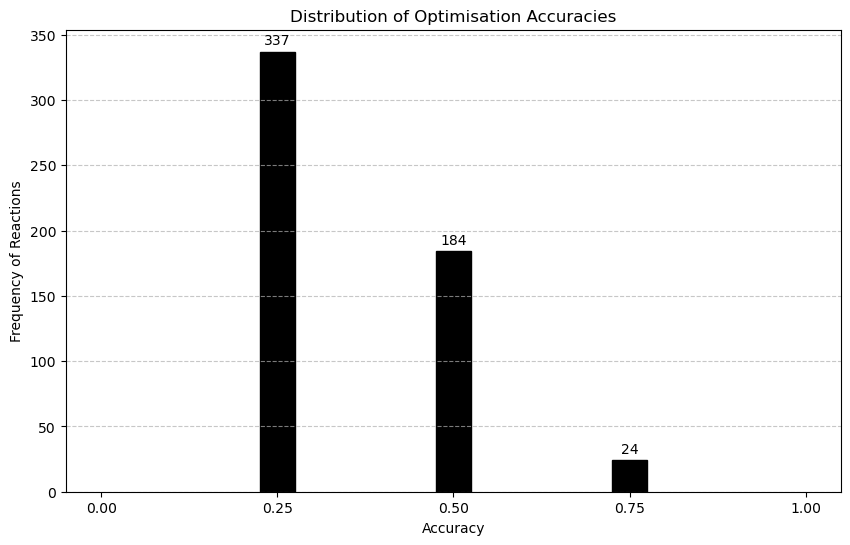

In [9]:
%%time
maximisation_result = lexoff(model,'biomass_cho_prod',1,1,late_qual_criteria_dict)

#### Observe the result dataframe

In [10]:
result_dataframe = maximisation_result[0]
result_dataframe

,EX_cu2(e),EX_eicostri(e),EX_docastri(e),EX_Rtotal(e),EX_Rtotal2(e),EX_Rtotal3(e),EX_4hphac(e),EX_4hpro(e),EX_34dhoxmand(e),EX_3mox4hoxm(e),...,EX_q10h2(e),EX_rbt(e),EX_sph1p(e),EX_spmd(e),EX_sprm(e),EX_s2l2fn2m2masn(e),EX_idour(e),EX_hcoumarin(e),EX_ha(e),EX_h2o(e)
criteria_reactions,,,,,,,,,,,,,,,,,,,,,
biomass_cho_prod,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,2.012313e-03,0.002012,0.002012,...,2.012313e-03,2.012313e-03,2.012313e-03,0.002012,0.002012,2.012313e-03,0.002012,0.002012,2.012313e-03,0.002012
ICproduct_Final_demand,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.705652e-34,0.000000,0.000000,...,9.264783e-07,9.264783e-07,3.220854e-07,0.000002,0.000002,2.194033e-19,0.000010,0.000004,6.763743e-34,0.000000
EX_lac_L(e),0.013852,0.013852,0.013852,0.013067,0.013067,0.013067,0.013067,1.306714e-02,0.013067,0.013067,...,-1.380689e-02,-1.380689e-02,-1.339933e-03,-0.001340,-0.001340,-1.338271e-02,-0.018089,-0.018089,-2.527654e-02,-0.025277
EX_nh4(e),0.102288,0.102288,0.102288,0.159525,0.159787,0.159787,0.143098,1.430415e-01,0.101696,0.102922,...,3.784375e-01,3.784375e-01,2.388094e-01,0.234661,0.238022,3.740711e-01,0.164998,0.212517,2.964163e-02,-0.077077
biomass_cho_prod,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000
ICproduct_Final_demand,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000e+00,0.000000,0.000000,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000
EX_lac_L(e),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,...,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000e+00,-1.000000
EX_nh4(e),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,-1.000000
accuracy,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,2.500000e-01,0.250000,0.250000,...,7.500000e-01,7.500000e-01,7.500000e-01,0.750000,0.750000,7.500000e-01,0.750000,0.750000,7.500000e-01,0.750000


#### Study the second optimisations (sanity check)

In [15]:
# Find those reactions with the maximum accuracy scores
max_accuracy = (result_dataframe.iloc[-1]).max()
reactions_with_max_accuracy = (result_dataframe.iloc[-1])[(result_dataframe.iloc[-1]) == max_accuracy].index.tolist()
print("Reactions with maximum accuracy:", reactions_with_max_accuracy)

# Find which metabolites are being exchanged in these reactions
print('')
print('The most accurate second optimisations include the maximisation of uptake of these metabolites:')
for r in reactions_with_max_accuracy:
    for m in model.reactions.get_by_id(r).metabolites:
        print(m.name)

Reactions with maximum accuracy: ['EX_ksi(e)', 'EX_idp(e)', 'EX_imp(e)', 'EX_ksii_core2(e)', 'EX_inost(e)', 'EX_ksii_core4(e)', 'EX_hxan(e)', 'EX_i(e)', 'EX_rib_D(e)', 'EX_ribflv(e)', 'EX_retn(e)', 'EX_retnglc(e)', 'EX_retinol(e)', 'EX_retfa(e)', 'EX_q10h2(e)', 'EX_rbt(e)', 'EX_sph1p(e)', 'EX_spmd(e)', 'EX_sprm(e)', 'EX_s2l2fn2m2masn(e)', 'EX_idour(e)', 'EX_hcoumarin(e)', 'EX_ha(e)', 'EX_h2o(e)']

The most accurate second optimisations include the maximisation of uptake of these metabolites:
keratan sulfate I
IDP(3-)
IMP
keratan sulfate II (core 2-linked)
myo-inositol
keratan sulfate II (core 4-linked)
hypoxanthine
iodide
D-ribose
Riboflavin
all-trans-retinoate
retinoyl glucuronide; all-trans-Retinoyl-beta-glucuronide
retinol
fatty acid retinol
Ubiquinol-10
D-ribitol
(2S,3R)-2-azaniumyl-3-hydroxyoctadecyl phosphate
Spermidine
spermine(4+)
PA6
L-iduronate
Umbelliferone; 7-Hydroxy-2H-1-Benzopyran-2-one
hyaluronan
H2O


### 4b. Run LEXOFF (example with minimisation of second optimisation)

Optimisation: User would like to maximise biomass_cho_prod, then explore the minimisation of exchange reactions as the second optimisation
The maximum accuracy is 0.75 and this has been achieved by 11 unique reactions for second optimisation, including the minimisation of: ['EX_pheme(e)', 'EX_phyQ(e)', 'EX_phyt(e)']
0.25 accuracy: 406 reactions
0.50 accuracy: 128 reactions
0.75 accuracy: 11 reactions
CPU times: total: 43.4 s
Wall time: 43.7 s


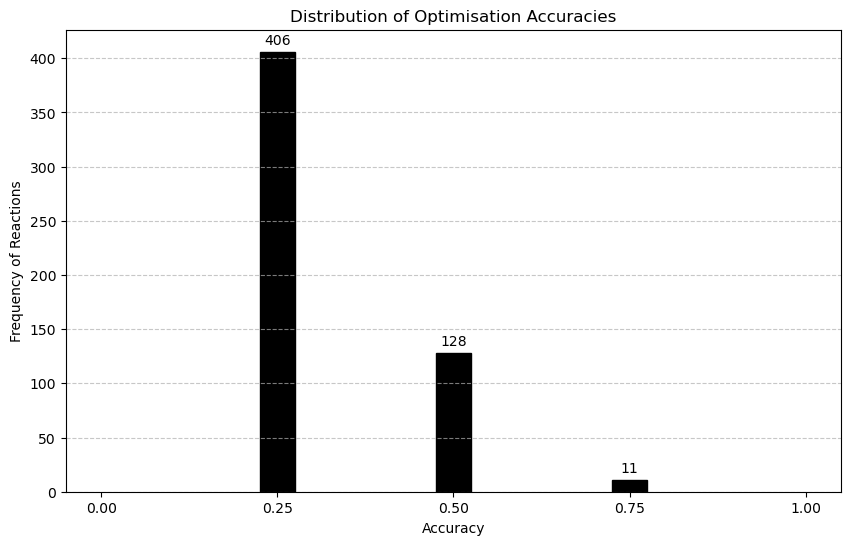

In [11]:
%%time
minimisation_result = lexoff(model,'biomass_cho_prod',1,-1,late_qual_criteria_dict)

#### Observe the result dataframe

In [12]:
result_dataframe_1 = minimisation_result[0]
result_dataframe_1

,EX_glcn(e),EX_10fthf5glu(e),EX_10fthf6glu(e),EX_10fthf7glu(e),EX_11_cis_retfa(e),EX_13_cis_retnglc(e),EX_1glyc_cho(e),EX_1mncam(e),EX_23cump(e),EX_2425dhvitd2(e),...,EX_phyQ(e),EX_phyt(e),EX_paf_cho(e),EX_pchol_cho(e),EX_pe_cho(e),EX_peplys(e),EX_perillyl(e),EX_pglyc_cho(e),EX_phe_L(e),EX_pheacgln(e)
criteria_reactions,,,,,,,,,,,,,,,,,,,,,
biomass_cho_prod,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,...,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012,0.002012
ICproduct_Final_demand,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001
EX_lac_L(e),0.002342,0.017240,0.017240,0.017240,0.017240,0.017240,0.017240,0.017240,0.017240,0.017240,...,-0.006208,-0.006208,-0.006208,-0.006208,-0.006208,-0.006208,-0.006208,-0.006208,-0.006208,-0.006208
EX_nh4(e),0.041890,0.064412,0.064412,0.064412,0.064412,0.064412,0.064412,0.064412,0.064412,0.064412,...,0.121217,0.121217,0.121217,0.121217,0.121217,0.121217,0.121217,0.121217,0.121217,0.121217
biomass_cho_prod,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
ICproduct_Final_demand,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EX_lac_L(e),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
EX_nh4(e),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
accuracy,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,0.250000,...,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000,0.750000


#### Study the the second optimisations

In [16]:
# Find those reactions with the maximum accuracy scores
max_accuracy = (result_dataframe_1.iloc[-1]).max()
reactions_with_max_accuracy = (result_dataframe_1.iloc[-1])[(result_dataframe_1.iloc[-1]) == max_accuracy].index.tolist()
print("Reactions with maximum accuracy:", reactions_with_max_accuracy)

# Find which metabolites are being exchanged in these reactions
print('')
print('The most accurate second optimisations include the minimisation of uptake of these metabolites:')
for r in reactions_with_max_accuracy:
    for m in model.reactions.get_by_id(r).metabolites:
        print(m.name)

Reactions with maximum accuracy: ['EX_pheme(e)', 'EX_phyQ(e)', 'EX_phyt(e)', 'EX_paf_cho(e)', 'EX_pchol_cho(e)', 'EX_pe_cho(e)', 'EX_peplys(e)', 'EX_perillyl(e)', 'EX_pglyc_cho(e)', 'EX_phe_L(e)', 'EX_pheacgln(e)']

The most accurate second optimisations include the minimisation of uptake of these metabolites:
Protoheme
phylloquinone
phytanate
1-alkyl 2-acteylglycerol 3-phosphocholine
Phosphatidylcholine
phosphatidylethanolamine
Peptidyl-L-lysine
perillyl alcohol
phosphatidylglycerol(1-)
L-phenylalanine
N(2)-phenylacetyl-L-glutamine
